In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 2️⃣ BigQuery client

PROJECT_ID = "bigquery-test-dilara-475511"
client = bigquery.Client(project=PROJECT_ID)

In [6]:
# 3️⃣ EXTRACT: NYC Yellow Taxi Trip Data (2019)

query_taxi = """
SELECT
  pickup_datetime,
  dropoff_datetime,
  passenger_count,
  trip_distance,
  fare_amount,
  tip_amount,
  pickup_location_id,
  dropoff_location_id
FROM `bigquery-public-data.new_york_taxi_trips.tlc_yellow_trips_2019`
WHERE pickup_datetime IS NOT NULL
LIMIT 50000
"""
df_taxi = client.query(query_taxi).to_dataframe()
print("✅ NYC Taxi Verisi Çekildi")
display(df_taxi.head())


✅ NYC Taxi Verisi Çekildi


,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,pickup_location_id,dropoff_location_id
0,2019-02-24 15:31:42+00:00,2019-02-24 15:32:54+00:00,1,0E-9,0E-9,0E-9,7,193
1,2019-02-05 10:09:02+00:00,2019-02-05 10:11:35+00:00,1,0E-9,0E-9,0E-9,193,193
2,2019-02-27 15:31:07+00:00,2019-02-27 15:31:51+00:00,1,0E-9,0E-9,0E-9,7,7
3,2019-02-07 10:41:24+00:00,2019-02-07 10:42:28+00:00,1,0E-9,0E-9,0E-9,193,193
4,2019-02-03 10:33:04+00:00,2019-02-03 10:33:31+00:00,2,0E-9,0E-9,0E-9,193,193


In [7]:
# 4️⃣ TRANSFORM: Temizlik ve Feature Engineering
df_taxi['pickup_datetime'] = pd.to_datetime(df_taxi['pickup_datetime'])
df_taxi['dropoff_datetime'] = pd.to_datetime(df_taxi['dropoff_datetime'])

# Trip duration (dakika cinsinden)
df_taxi['trip_duration_min'] = (df_taxi['dropoff_datetime'] - df_taxi['pickup_datetime']).dt.total_seconds() / 60

# Outlier filtresi
df_taxi = df_taxi[(df_taxi['trip_duration_min'] > 1) & (df_taxi['trip_duration_min'] < 180)]
df_taxi = df_taxi[(df_taxi['fare_amount'] > 0) & (df_taxi['fare_amount'] < 500)]

# Passenger count filtre
df_taxi = df_taxi[(df_taxi['passenger_count'] > 0) & (df_taxi['passenger_count'] <= 6)]

# Yeni feature: tip yüzdesi
df_taxi['tip_pct'] = df_taxi['tip_amount'] / df_taxi['fare_amount'] * 100

# Pickup hour ve weekday
df_taxi['pickup_hour'] = df_taxi['pickup_datetime'].dt.hour
df_taxi['pickup_weekday'] = df_taxi['pickup_datetime'].dt.weekday

print("✅ Transform ve Feature Engineering Tamamlandı")
display(df_taxi.head())

✅ Transform ve Feature Engineering Tamamlandı


,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,pickup_location_id,dropoff_location_id,trip_duration_min,tip_pct,pickup_hour,pickup_weekday
85,2019-02-23 18:41:11+00:00,2019-02-23 18:43:06+00:00,1,0.010000000,0.100000000,0E-9,191,191,1.916667,0,18,5
86,2019-02-06 07:38:06+00:00,2019-02-06 07:42:21+00:00,1,1.070000000,0.100000000,0E-9,265,19,4.250000,0,7,2
87,2019-02-13 08:13:01+00:00,2019-02-13 08:15:37+00:00,1,0E-9,0.100000000,0E-9,191,191,2.600000,0,8,2
88,2019-02-11 17:34:05+00:00,2019-02-11 17:35:15+00:00,1,0E-9,0.100000000,0E-9,191,191,1.166667,0,17,0
90,2019-02-13 07:35:37+00:00,2019-02-13 07:44:00+00:00,1,1.710000000,0.100000000,0E-9,191,19,8.383333,0,7,2


In [8]:
# 5️⃣ AGGREGATION: Saat ve lokasyon bazlı analiz
# Saat bazında ortalama trip_duration ve tip yüzdesi

df_hourly = df_taxi.groupby('pickup_hour').agg({
    'trip_duration_min':'mean',
    'tip_pct':'mean',
    'fare_amount':'sum'
}).reset_index()

print("✅ Saat Bazlı Aggregation Tamamlandı")
display(df_hourly)

# Lokasyon bazlı toplam fare ve ortalama mesafe

df_location = df_taxi.groupby('pickup_location_id').agg({
    'fare_amount':'sum',
    'tip_amount':'sum',
    'trip_distance':'mean'
}).reset_index()

print("✅ Lokasyon Bazlı Aggregation Tamamlandı")
display(df_location)

✅ Saat Bazlı Aggregation Tamamlandı


,pickup_hour,trip_duration_min,tip_pct,fare_amount
0,0,25.738095,7.685939,2197.430000000
1,1,23.367949,10.239166,1218.710000000
2,2,17.168182,6.952816,424.690000000
3,3,26.659722,8.118645,579.600000000
4,4,26.461111,5.95979,820.960000000
5,5,18.048837,12.129223,2240.250000000
6,6,11.546922,16.272088,23154.700000000
7,7,12.662821,18.272803,38767.390000000
8,8,14.147481,19.048569,51554.190000000
9,9,13.911826,18.582195,52114.090000000


✅ Lokasyon Bazlı Aggregation Tamamlandı


,pickup_location_id,fare_amount,tip_amount,trip_distance
0,10,850.960000000,91.080000000,14.385294
1,100,10671.970000000,1708.980000000,2.091182
2,101,87.340000000,0E-9,15.435
3,102,9.000000000,0E-9,2.03
4,106,52.000000000,0E-9,8.3075
...,...,...,...,...
222,94,15.380000000,0E-9,3.52
223,95,262.200000000,0E-9,7.400909
224,96,11.500000000,0E-9,3.12
225,97,462.020000000,33.380000000,3.626333


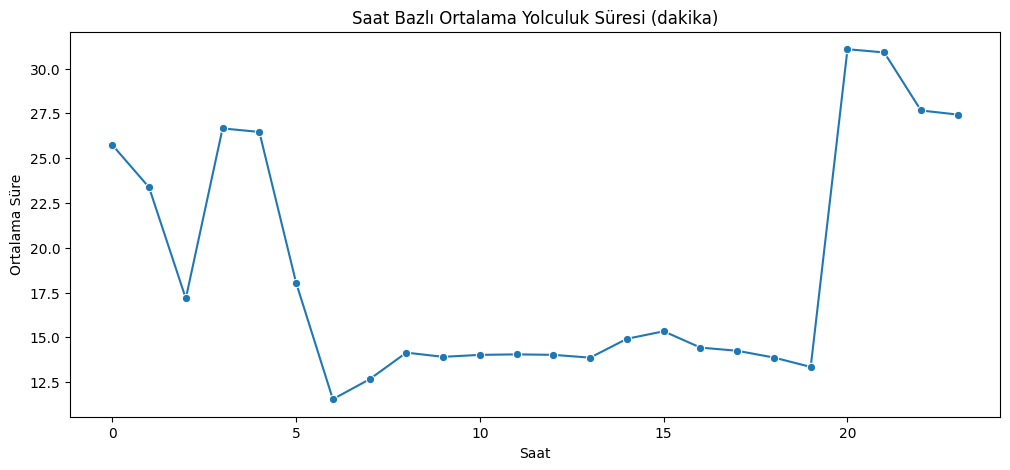

/tmp/ipython-input-3473230414.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_location.head(20), x='pickup_location_id', y='fare_amount', palette="Blues_r")


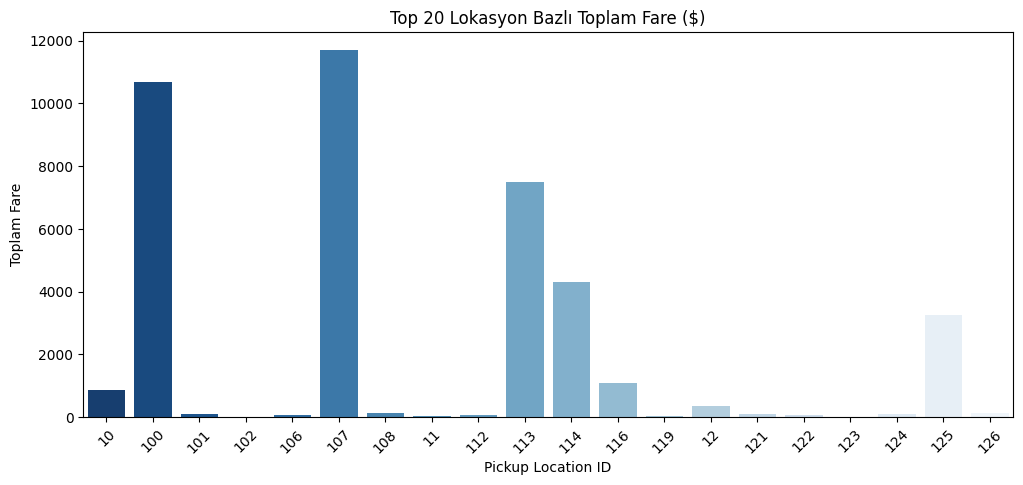

In [9]:
# 6️⃣ GÖRSELLEŞTİRME

plt.figure(figsize=(12,5))
sns.lineplot(data=df_hourly, x='pickup_hour', y='trip_duration_min', marker='o')
plt.title("Saat Bazlı Ortalama Yolculuk Süresi (dakika)")
plt.xlabel("Saat")
plt.ylabel("Ortalama Süre")
plt.show()

plt.figure(figsize=(12,5))
sns.barplot(data=df_location.head(20), x='pickup_location_id', y='fare_amount', palette="Blues_r")
plt.title("Top 20 Lokasyon Bazlı Toplam Fare ($)")
plt.xlabel("Pickup Location ID")
plt.ylabel("Toplam Fare")
plt.xticks(rotation=45)
plt.show()

In [10]:
# ETL sonrası sonucu CSV olarak kaydet
# LOAD

df_taxi.to_csv("nyc_taxi_etl.csv", index=False)
print("✅ ETL sonucu CSV olarak kaydedildi: nyc_taxi_etl.csv")


✅ ETL sonucu CSV olarak kaydedildi: nyc_taxi_etl.csv


In [12]:
dataset_id = f"{PROJECT_ID}.nyc_etl"

# Dataset nesnesi oluştur
from google.cloud import bigquery

dataset = bigquery.Dataset(dataset_id)
dataset.location = "US"

# Dataset oluştur, yoksa
dataset = client.create_dataset(dataset, exists_ok=True)
print(f"✅ Dataset oluşturuldu veya zaten mevcut: {dataset_id}")

✅ Dataset oluşturuldu veya zaten mevcut: bigquery-test-dilara-475511.nyc_etl


In [13]:
table_id = f"{dataset_id}.yellow_taxi_etl"

job = client.load_table_from_dataframe(df_taxi, table_id)
job.result()  # Yüklemenin bitmesini bekle
print(f"✅ ETL sonucu BigQuery’ye yüklendi: {table_id}")

✅ ETL sonucu BigQuery’ye yüklendi: bigquery-test-dilara-475511.nyc_etl.yellow_taxi_etl


In [20]:
query = """
SELECT *
FROM `bigquery-test-dilara-475511.nyc_etl.yellow_taxi_etl`
LIMIT 10
"""
df_preview = client.query(query).to_dataframe()
df_preview.head()


,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,pickup_location_id,dropoff_location_id,trip_duration_min,tip_pct,pickup_hour,pickup_weekday
0,2019-02-11 17:34:05+00:00,2019-02-11 17:35:15+00:00,1,0E-9,0.100000000,0E-9,191,191,1.166667,0E-38,17,0
1,2019-02-18 07:47:35+00:00,2019-02-18 07:50:38+00:00,1,0E-9,0.100000000,0E-9,191,191,3.050000,0E-38,7,0
2,2019-02-11 05:36:00+00:00,2019-02-11 05:38:19+00:00,1,0.560000000,0.010000000,0E-9,265,265,2.316667,0E-38,5,0
3,2019-02-11 15:43:44+00:00,2019-02-11 15:49:36+00:00,1,1.100000000,0.010000000,0E-9,134,197,5.866667,0E-38,15,0
4,2019-02-25 12:56:57+00:00,2019-02-25 13:31:53+00:00,1,0.010000000,2.500000000,0E-9,22,123,34.933333,0E-38,12,0
